In [1]:
# Train and Evaluate
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = pd.read_csv('../data/processed/features.csv')
drop_cols = ['customer_unique_id','churned','recency','monetary','segment']
X = features.drop(columns=[c for c in drop_cols if c in features.columns])
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['Not Churned','Churned']))
# Write down the RECALL score for 'Churned' — this is your resume number

              precision    recall  f1-score   support

 Not Churned       0.72      0.43      0.54      5575
     Churned       0.87      0.96      0.91     22430

    accuracy                           0.85     28005
   macro avg       0.80      0.70      0.73     28005
weighted avg       0.84      0.85      0.84     28005



In [2]:

# Find At-Risk Revenue (Most Important Output)
# Add churn probability to all customers
X_all = features.drop(columns=[c for c in drop_cols if c in features.columns])
features['churn_prob'] = model.predict_proba(X_all)[:,1]

# High-value at-risk = top 20% spenders + high churn probability
at_risk = features[
    (features['churn_prob'] > 0.6) &
    (features['monetary'] > features['monetary'].quantile(0.8))
]

print('HIGH-VALUE AT-RISK CUSTOMERS:', len(at_risk))
print('REVENUE AT RISK: R$', round(at_risk['monetary'].sum(), 2))
# WRITE THESE NUMBERS DOWN — they go in your resume bullets

# Export final file for Power BI
rfm = pd.read_csv('../data/processed/rfm_scores.csv')
final = features.merge(rfm[['customer_unique_id','segment']], on='customer_unique_id', how='left')
final.to_csv('../outputs/final_analytics.csv', index=False)
print('Final analytics exported!')

HIGH-VALUE AT-RISK CUSTOMERS: 15238
REVENUE AT RISK: R$ 6741824.98
Final analytics exported!


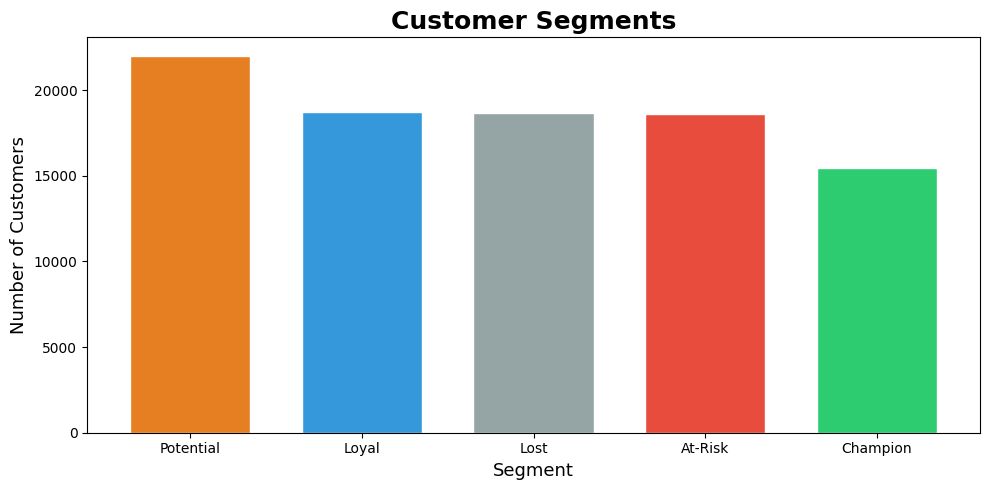

In [5]:
# Visual 1 — RFM Segment Bar Chart
import matplotlib.pyplot as plt
import pandas as pd

rfm = pd.read_csv('../data/processed/rfm_scores.csv')
plt.figure(figsize=(10,5))
segment_counts = rfm['segment'].value_counts()
seg_colors = {
    'Champion':'#2ECC71',
    'Loyal':'#3498DB',
    'Potential':'#E67E22',
    'At-Risk':'#E74C3C',
    'Lost':'#95A5A6'
}
colors_list = [seg_colors.get(s,'#3498DB') for s in segment_counts.index]
segment_counts.plot(kind='bar', color=colors_list, edgecolor='white', width=0.7)
plt.title('Customer Segments', fontsize=18, fontweight='bold')
plt.xlabel('Segment', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

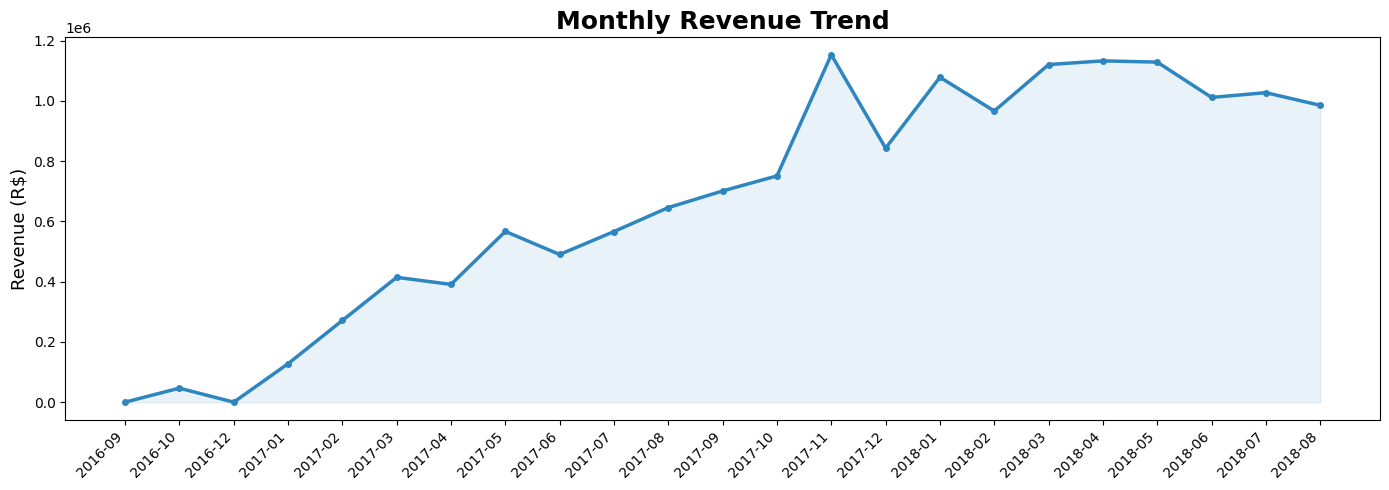

In [3]:
# Monthly Revenue Trend Visualization
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset (adjust path if needed)
df = pd.read_csv('../data/processed/golden_dataset.csv', parse_dates=['order_purchase_timestamp'])

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly = df.groupby('month')['payment_value'].sum().reset_index()
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(14,5))
plt.plot(range(len(monthly)), monthly['payment_value'],
         color='#2E86C1', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(range(len(monthly)), monthly['payment_value'],
                 alpha=0.1, color='#2E86C1')
plt.title('Monthly Revenue Trend', fontsize=18, fontweight='bold')
plt.xticks(range(len(monthly)), monthly['month_str'], rotation=45, ha='right')
plt.ylabel('Revenue (R$)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

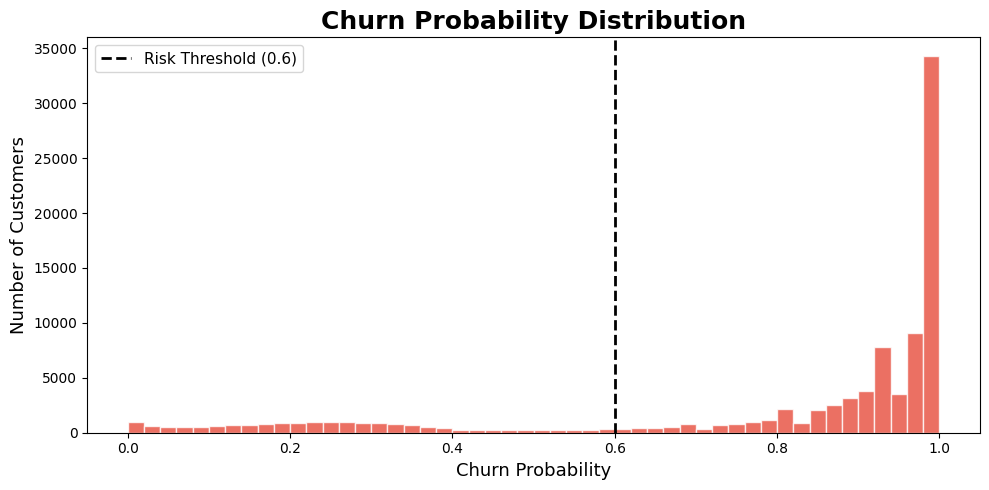

In [4]:
# Churn Probability Distribution Visualization
plt.figure(figsize=(10,5))
plt.hist(features['churn_prob'], bins=50, color='#E74C3C', edgecolor='white', alpha=0.8)
plt.axvline(0.6, color='black', linestyle='--', linewidth=2, label='Risk Threshold (0.6)')
plt.title('Churn Probability Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Churn Probability', fontsize=13)
plt.ylabel('Number of Customers', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

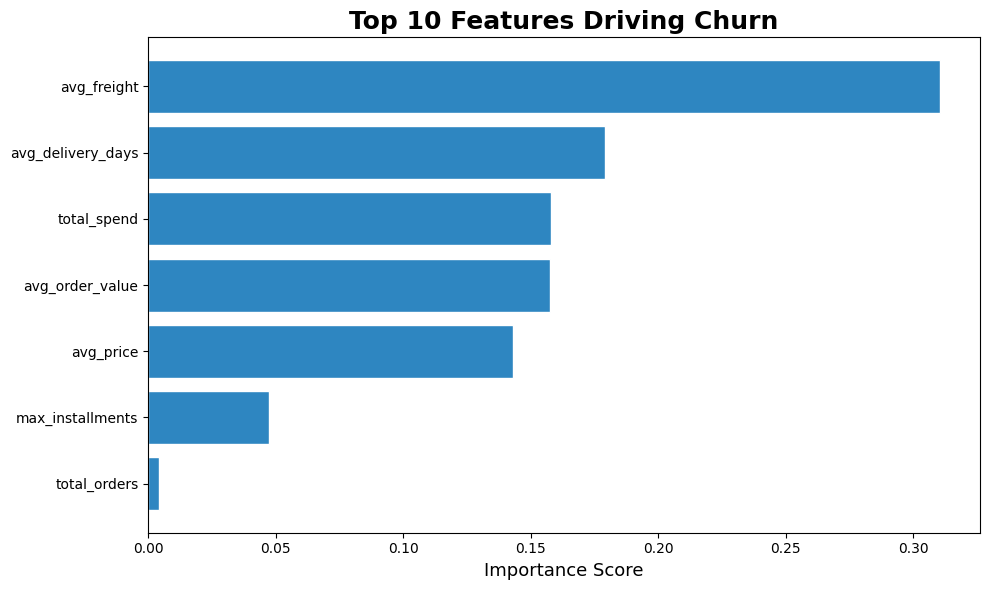

In [5]:
# Top 10 Features Driving Churn
importance_df = pd.DataFrame({
    'feature' : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='#2E86C1', edgecolor='white')
plt.title('Top 10 Features Driving Churn', fontsize=18, fontweight='bold')
plt.xlabel('Importance Score', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

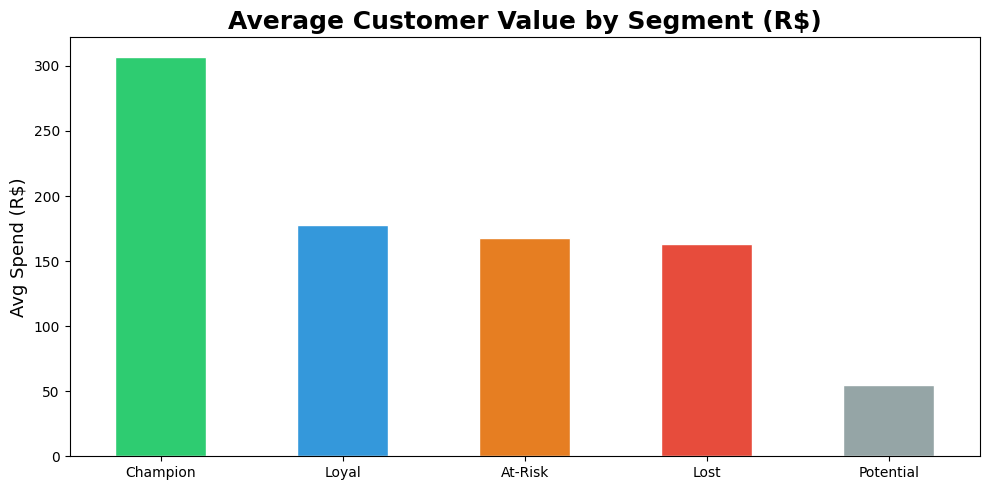

In [6]:
# Average Customer Value by Segment (CLV)
rfm_data = pd.read_csv('../data/processed/rfm_scores.csv')
seg_revenue = rfm_data.groupby('segment')['monetary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
seg_colors = ['#2ECC71','#3498DB','#E67E22','#E74C3C','#95A5A6']
seg_revenue.plot(kind='bar', color=seg_colors[:len(seg_revenue)], edgecolor='white')
plt.title('Average Customer Value by Segment (R$)', fontsize=18, fontweight='bold')
plt.xlabel('')
plt.ylabel('Avg Spend (R$)', fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

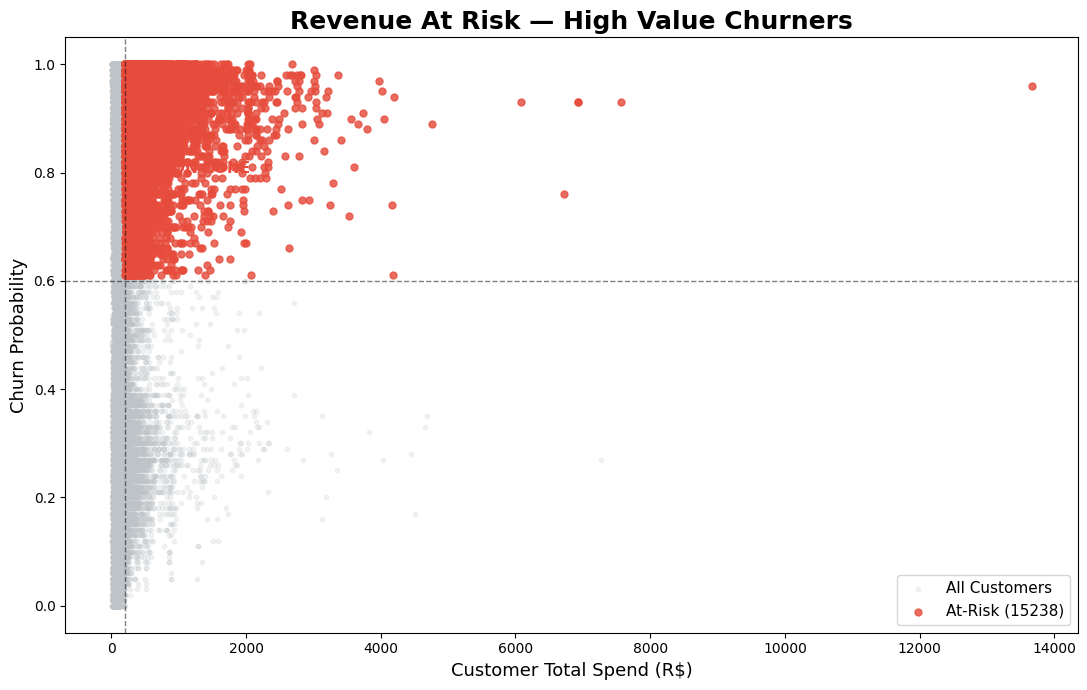

Customers in action zone: 15238
Revenue at risk: R$ 6,741,824.98


In [7]:
# Revenue At Risk — High Value Churners
plt.figure(figsize=(11,7))

# All customers in grey
plt.scatter(features['monetary'], features['churn_prob'],
            alpha=0.2, color='#BDC3C7', s=10, label='All Customers')

# High-value at-risk in red
at_risk = features[
    (features['churn_prob'] > 0.6) &
    (features['monetary'] > features['monetary'].quantile(0.8))
]
plt.scatter(at_risk['monetary'], at_risk['churn_prob'],
            alpha=0.8, color='#E74C3C', s=25, label=f'At-Risk ({len(at_risk)})')

# Threshold lines
plt.axhline(0.6, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(features['monetary'].quantile(0.8),
            color='black', linestyle='--', linewidth=1, alpha=0.5)

# Annotate the danger zone
plt.annotate('ACTION ZONE',
             xy=(features['monetary'].quantile(0.9), 0.8),
             fontsize=11, color='#E74C3C', fontweight='bold')

plt.title('Revenue At Risk — High Value Churners', fontsize=18, fontweight='bold')
plt.xlabel('Customer Total Spend (R$)', fontsize=13)
plt.ylabel('Churn Probability', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/at_risk_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Customers in action zone: {len(at_risk)}')
print(f'Revenue at risk: R$ {at_risk["monetary"].sum():,.2f}')